In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

COL_PD = '#ca3335'
COL_HEALTHY = '#467ba7'

In [ ]:
df = pd.read_csv('data/2025_parkinsons.csv')
df = df.dropna().reset_index(drop=True)

features = [c for c in df.columns if c not in ['name', 'status']]

df['Diagnosis'] = df['status'].map({1: 'PD', 0: 'Healthy'})

pd_df = df[df['status'] == 1]
healthy_df = df[df['status'] == 0]

print(f'PD recordings: {len(pd_df)}, Healthy: {len(healthy_df)}')
print(f'Features: {len(features)}')

PD recordings: 141  |  Healthy: 44
Features: 22


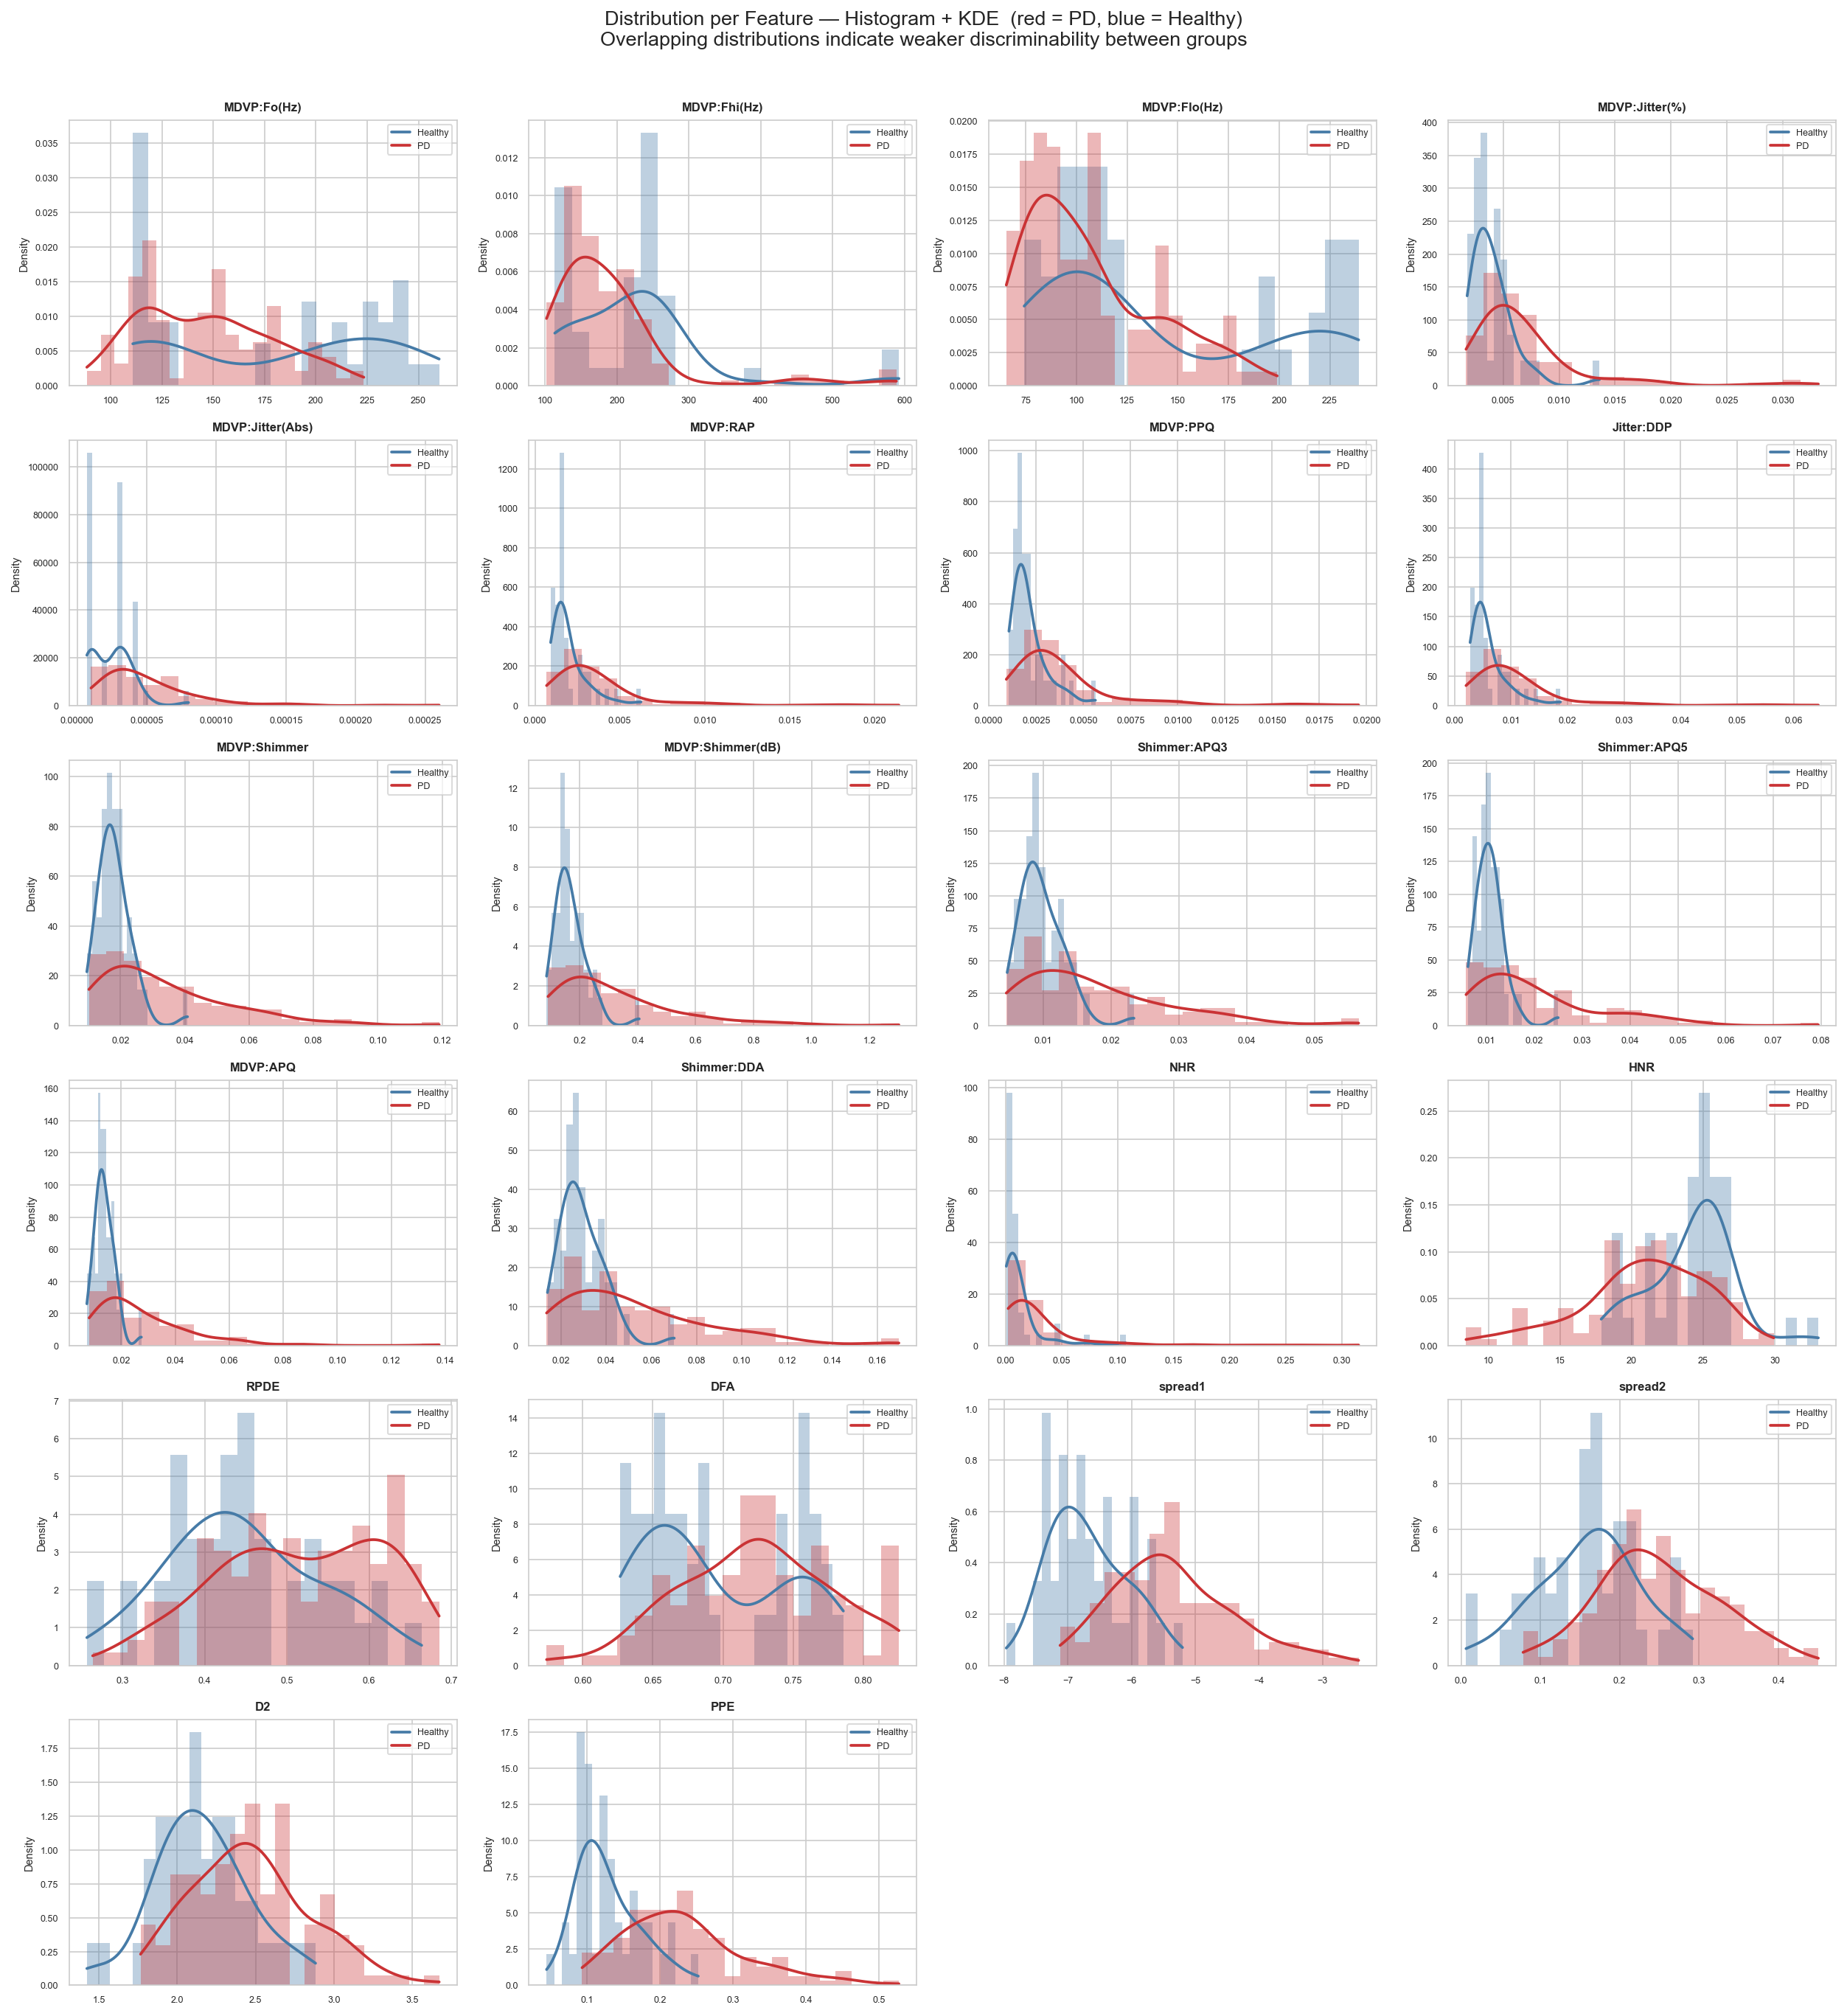

In [ ]:
# Histogram + KDE per feature, split by group
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.0))
axes_flat = axes.flatten()

for i, feat in enumerate(features):
    ax = axes_flat[i]

    for g, label, color in [(0, 'Healthy', COL_HEALTHY), (1, 'PD', COL_PD)]:
        vals = df.loc[df['status'] == g, feat].dropna()
        # Histogram
        ax.hist(vals, bins=20, color=color, alpha=0.35, density=True,
                edgecolor='none', label=None)
        # KDE curve
        if len(vals) > 4:  # need at least a few points for KDE
            kde = stats.gaussian_kde(vals)
            x_grid = np.linspace(vals.min(), vals.max(), 200)
            ax.plot(x_grid, kde(x_grid), color=color, linewidth=1.8, label=label)

    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6, framealpha=0.7)

for j in range(len(features), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Distribution per Feature: Histogram + KDE  (red = PD, blue = Healthy)\n'
    'Overlapping distributions indicate weaker discriminability between groups',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('plots/distribution_hist_kde.png', dpi=200, bbox_inches='tight')
plt.show()

In [4]:
# summary statistics for each feature across every group
rows = []
for feat in features:
    for g, label in [(0, 'Healthy'), (1, 'PD')]:
        vals = df.loc[df['status'] == g, feat].dropna()
        rows.append({
            'Feature': feat,
            'Group': label,
            'n': len(vals),
            'Median': np.median(vals),
            'Mean': vals.mean(),
            'Std': vals.std(),
            'Skewness': stats.skew(vals),
        })

summary = pd.DataFrame(rows)

# Pivot to wide format for easy comparison
pivot = summary.pivot(index='Feature', columns='Group', values=['Median', 'Mean', 'Std', 'Skewness'])
pivot.columns = [f'{col[1]} {col[0]}' for col in pivot.columns]
pivot = pivot[[c for c in sorted(pivot.columns)]]
print(pivot.round(4).to_string())

                  Healthy Mean  Healthy Median  Healthy Skewness  Healthy Std   PD Mean  PD Median  PD Skewness   PD Std
Feature                                                                                                                 
D2                      2.1575          2.1295            0.1344       0.3053    2.4646     2.4429       0.4545   0.3768
DFA                     0.6940          0.6803            0.3908       0.0513    0.7232     0.7238      -0.1302   0.0543
HNR                    24.1960         24.8730            0.1079       3.0159   20.9096    21.3780      -0.6108   4.3674
Jitter:DDP              0.0060          0.0050            2.0777       0.0033    0.0114     0.0085       2.9768   0.0099
MDVP:APQ                0.0137          0.0134            1.0985       0.0037    0.0278     0.0215       2.3305   0.0183
MDVP:Fhi(Hz)          223.6544        232.9820            2.0441     100.8965  190.4060   163.4170       2.7306  89.4766
MDVP:Flo(Hz)          139.8460  

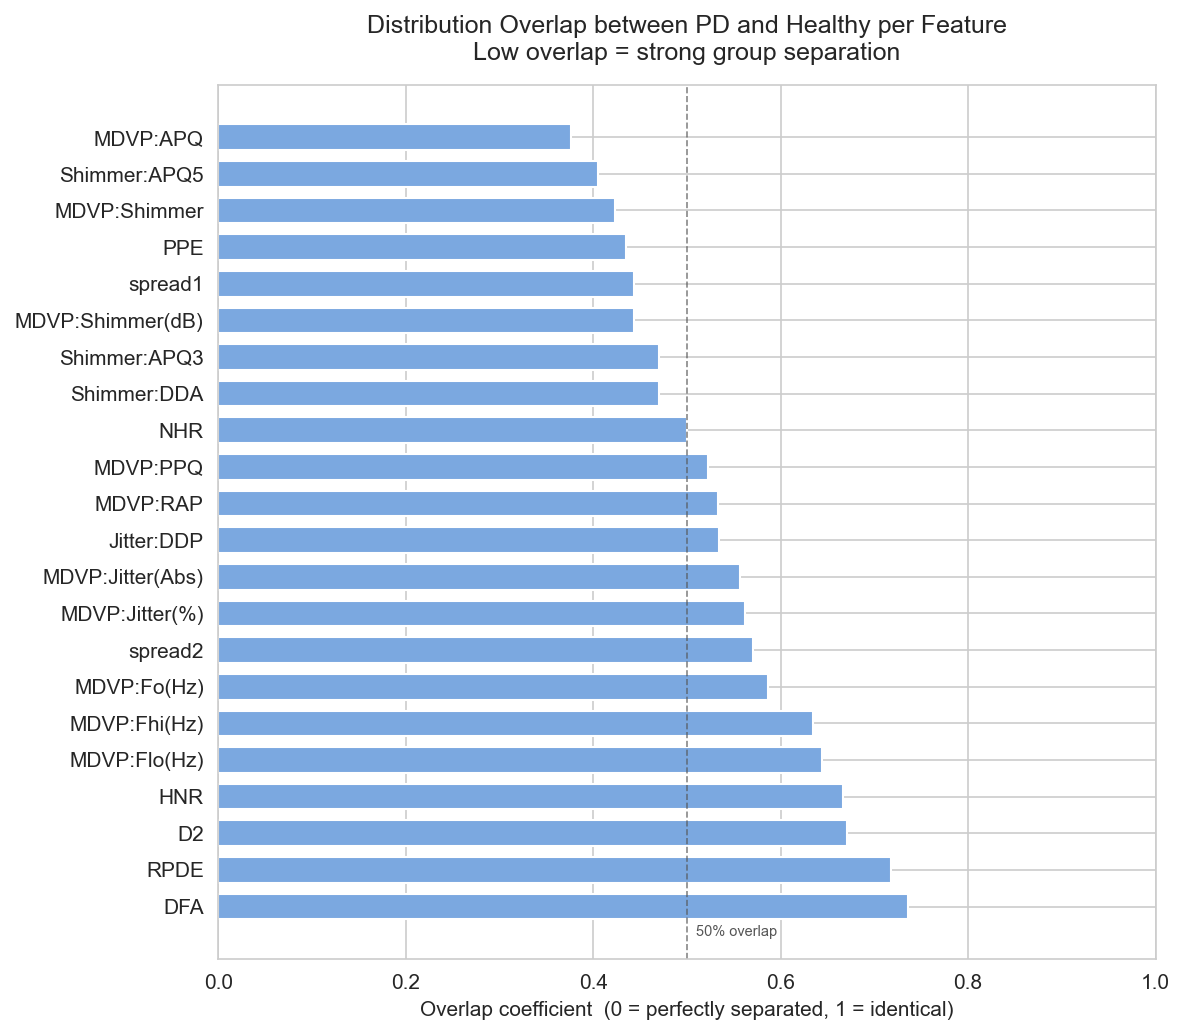

In [5]:
# Overlap coefficient per feature: area under min(KDE_PD, KDE_healthy)
# A value of 1 = identical distributions; 0 = perfectly separated
overlap_rows = []
for feat in features:
    vals_pd  = df.loc[df['status'] == 1, feat].dropna().values
    vals_h   = df.loc[df['status'] == 0, feat].dropna().values
    if len(vals_pd) < 5 or len(vals_h) < 5:
        continue
    x_min = min(vals_pd.min(), vals_h.min())
    x_max = max(vals_pd.max(), vals_h.max())
    x_grid = np.linspace(x_min, x_max, 500)
    kde_pd = stats.gaussian_kde(vals_pd)(x_grid)
    kde_h  = stats.gaussian_kde(vals_h)(x_grid)
    overlap = np.trapezoid(np.minimum(kde_pd, kde_h), x_grid)
    overlap_rows.append({'Feature': feat, 'overlap_coeff': overlap})

overlap_df = pd.DataFrame(overlap_rows).sort_values('overlap_coeff')

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(overlap_df['Feature'], overlap_df['overlap_coeff'],
        color='#7BA8E0', edgecolor='white', height=0.7)
ax.axvline(0.5, color='#555555', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(0.51, len(overlap_df) - 0.5, '50% overlap', fontsize=7,
        color='#555555', va='top')
ax.set_xlabel('Overlap coefficient  (0 = perfectly separated, 1 = identical)', fontsize=10)
ax.set_title(
    'Distribution Overlap between PD and Healthy per Feature\n'
    'Low overlap = strong group separation',
    fontsize=12, pad=12
)
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/distribution_overlap.png', dpi=200, bbox_inches='tight')
plt.show()